In [8]:
import uproot
import numpy as np

In [95]:
m_mu = 105.658 #MeV

file = uproot.open("EnergyLossStoLih500Mev.root")

before = file["VirtualDetector/DetBefore"]
after  = file["VirtualDetector/DetAfter"]

px_b = before["Px"].array(library="np")
py_b = before["Py"].array(library="np")
pz_b = before["Pz"].array(library="np")

px_a = after["Px"].array(library="np")
py_a = after["Py"].array(library="np")
pz_a = after["Pz"].array(library="np")

p_b = np.sqrt(px_b**2 + py_b**2 + pz_b**2)
p_a = np.sqrt(px_a**2 + py_a**2 + pz_a**2)

E_b = np.sqrt(p_b**2 + m_mu**2)
E_a = np.sqrt(p_a**2 + m_mu**2)

dE = E_b - E_a
#print(dE)
print("Mean dE =", np.mean(dE), "MeV")


Mean dE = 0.45041138 MeV


In [96]:
#Stopping power
length = 0.25 # cm from g4bl card
dEdx_g4bl = np.mean(dE) / 0.25 

print(dEdx_g4bl)


1.8016455


In [102]:

def bethe_bloch(p, m, Z, A, I_eV, density, z=1):
    """
    Compute dE/dx using Bethe-Bloch formula (simplified).

    Parameters:
    p : momentum (MeV/c)
    m : mass (MeV/c^2)
    Z : atomic number
    A : atomic mass (g/mol)
    I_eV : mean excitation energy (eV)
    density : g/cm^3
    z : projectile charge (muon = 1)
    """

    # constants
    K = 0.307075  # MeV cm^2 / mol
    me = 0.511    # MeV

    # convert I to MeV
    I = I_eV * 1e-6

    # kinematics
    E = np.sqrt(p**2 + m**2)
    beta = p / E
    gamma = E / m

    # Tmax (maximum energy transfer)
    Tmax = (2 * me * beta**2 * gamma**2) / (1 + 2*gamma*me/m + (me/m)**2)

    # Bethe-Bloch
    term1 = 0.5 * np.log((2 * me * beta**2 * gamma**2 * Tmax) / (I**2))
    term2 = beta**2

    dedx = K * (Z / A) * (1 / beta**2) * (term1 - term2)

    # convert to MeV/cm
    return dedx * density


# -------------------------
# carbon + muon
# -------------------------

p = 500.0        # MeV/c
m_mu = 105.658   # MeV/c^2

Z = 6
A = 12.011
density = 1.69   # g/cm^3
I_eV =  81        # carbon

dEdx = bethe_bloch(p, m_mu, Z, A, I_eV, density)

print("dE/dx =", dEdx, "MeV/cm")



dE/dx = 3.14397874316139 MeV/cm


In [93]:
print(abs(dEdx_g4bl-dEdxLi)/dEdxLi*100)

92.1200059798362


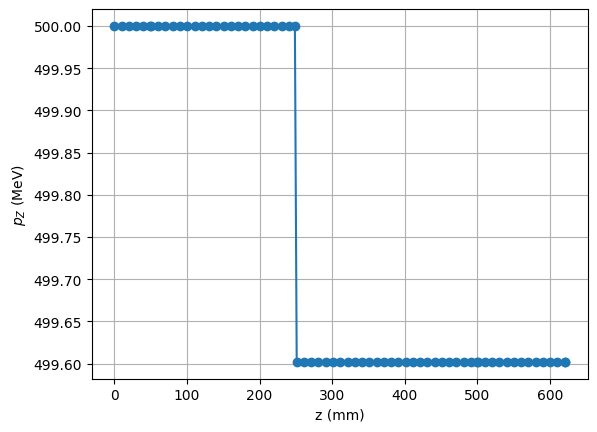

In [88]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("trace.txt", comments="#")

# Extract columns
z  = data[:,2]
px = data[:,3]
py = data[:,4]
pz = data[:,5]
eventID = data[:,8]

# -------------------------
# FILTER EVENT -2
# -------------------------

mask_evt = (eventID == -2)

z_evt  = z[mask_evt]
px_evt = px[mask_evt]
py_evt = py[mask_evt]
pz_evt = pz[mask_evt]

plt.plot(z_evt, pz_evt, marker='o')
plt.xlabel("z (mm)")
plt.ylabel("$p_{Z}$ (MeV)")
#plt.title("Energy Loss inside Carbon Target")
plt.grid()
#plt.xlim(200,400)
plt.show()



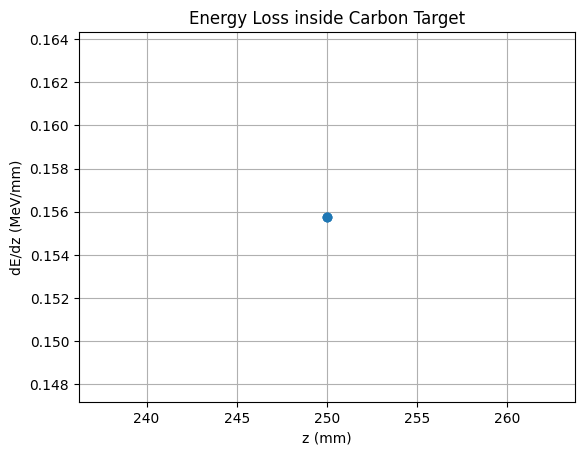

Mean dE/dz in target = 0.15575763326439757 MeV/mm


In [89]:
m = 105.658  # MeV

# energy per step
p = np.sqrt(px**2 + py**2 + pz**2)
E = np.sqrt(p**2 + m**2)

# dE/dz
dE = np.diff(E)
dz = np.diff(z)

dEdz = dE / dz
z_mid = 0.5 * (z[:-1] + z[1:])

# -----------------------------
# SELECT TARGET REGION ONLY
# -----------------------------
#z_min = 198.75 # 98.75
#z_max = 901.25 #101.25

z_min = 248.75
z_max = 251.25

mask = (z_mid >= z_min) & (z_mid <= z_max)

z_target = z_mid[mask]
dEdz_target = dEdz[mask]

# -----------------------------
# PLOT ONLY TARGET REGION
# -----------------------------
plt.plot(z_target, abs(dEdz_target), marker='o')
plt.xlabel("z (mm)")
plt.ylabel("dE/dz (MeV/mm)")
plt.title("Energy Loss inside Carbon Target")
plt.grid()
plt.show()

print("Mean dE/dz in target =", np.mean(abs(dEdz_target)), "MeV/mm")

# Wedge absorber

In [100]:
import uproot
import numpy as np

# =========================================================
# LOAD DATA
# =========================================================
file = uproot.open("EnergyLossWedgeSto.root")

before = file["VirtualDetector/DetBefore"].arrays(library="np")
after  = file["VirtualDetector/DetAfter"].arrays(library="np")

# =========================================================
# MOMENTUM
# =========================================================
px_b, py_b, pz_b = before["Px"], before["Py"], before["Pz"]
px_a, py_a, pz_a = after["Px"], after["Py"], after["Pz"]

p_b = np.sqrt(px_b**2 + py_b**2 + pz_b**2)
p_a = np.sqrt(px_a**2 + py_a**2 + pz_a**2)

# =========================================================
# ENERGY
# =========================================================
m_mu = 105.658

E_b = np.sqrt(p_b**2 + m_mu**2)
E_a = np.sqrt(p_a**2 + m_mu**2)

dE = E_b - E_a

mean_dE = np.mean(dE)
print("Mean energy loss (MeV):", mean_dE)

# =========================================================
# BETHE-BLOCH (LiH)
# =========================================================
def bethe_bloch(p, m, Z_over_A, I_eV, density):
    K = 0.307075
    me = 0.511

    I = I_eV * 1e-6

    E = np.sqrt(p**2 + m**2)
    beta = p / E
    gamma = E / m

    Tmax = (2 * me * beta**2 * gamma**2) / (
        1 + 2*gamma*me/m + (me/m)**2
    )

    term1 = 0.5 * np.log((2 * me * beta**2 * gamma**2 * Tmax) / (I**2))
    term2 = beta**2

    return K * Z_over_A * (1 / beta**2) * (term1 - term2) * density

# =========================================================
# LiH MATERIAL
# =========================================================
# Z_Li, A_Li = 3, 6.94
# Z_H,  A_H  = 1, 1.008

# w_Li = A_Li / (A_Li + A_H)
# w_H  = A_H  / (A_Li + A_H)

# Z_over_A = w_Li * (Z_Li / A_Li) + w_H * (Z_H / A_H)

# density = 0.82
# I_eV = 43

# Atomic numbers and standard atomic weights (PDG 2024)
Z_Li, A_Li = 3,  6.941    # natural lithium
Z_H,  A_H  = 1,  1.008    # hydrogen

# --- Mass fractions (1:1 atomic ratio in LiH) ---
M_LiH = A_Li + A_H        # formula mass = 7.949 g/mol
w_Li  = A_Li / M_LiH      # 0.8733
w_H   = A_H  / M_LiH      # 0.1267

print(f"w_Li = {w_Li:.4f},  w_H = {w_H:.4f}  (should sum to 1: {w_Li+w_H:.4f})")

# --- <Z/A> mixture ---
ZoverA_Li = Z_Li / A_Li   # 0.4323
ZoverA_H  = Z_H  / A_H    # 0.9921

Z_over_A = w_Li * ZoverA_Li + w_H * ZoverA_H
print(f"<Z/A> = {Z_over_A:.4f}  (PDG LiH = 0.504)")

# --- Mean excitation energy I via PDG log-mean rule ---
# I values: PDG Table 33.1
I_Li_eV = 40.0    # eV — elemental Li
I_H_eV  = 19.2    # eV — atomic H bound in compound (NOT 15.0 eV for H2 gas)

ln_I_mix = (w_Li * ZoverA_Li * np.log(I_Li_eV) +
            w_H  * ZoverA_H  * np.log(I_H_eV)) / Z_over_A


I_mix_eV = np.exp(ln_I_mix)
print(f"I_LiH  = {I_mix_eV:.1f} eV  (literature ~36 eV)")

# --- Density ---
density = 0.82    # g/cm3  (standard LiH, PDG agrees)

# --- Bethe-Bloch call with corrected inputs ---
dEdx_bb = bethe_bloch(p_b, m_mu, Z_over_A, I_mix_eV, density)
mean_dEdx_bb = np.mean(dEdx_bb)
print(f"Bethe-Bloch dE/dx = {mean_dEdx_bb:.4f} MeV/cm")

#dEdx_bb = bethe_bloch(p_b, m_mu, Z_over_A, I_eV, density)

#mean_dEdx_bb = np.mean(dEdx_bb)

#print("Bethe-Bloch dE/dx (MeV/cm):", mean_dEdx_bb)

# =========================================================
# EFFECTIVE PATH LENGTH (THIS IS THE KEY FIX)
# =========================================================
# Instead of guessing geometry, we invert physics:

L_eff_cm = mean_dE / mean_dEdx_bb

print("\n--- RESULTS ---")
print("Mean ΔE (MeV):", mean_dE)
print("Effective path length (cm):", L_eff_cm)
print("Bethe-Bloch dE/dx:", mean_dEdx_bb)

Mean energy loss (MeV): 105.54488
w_Li = 0.8732,  w_H = 0.1268  (should sum to 1: 1.0000)
<Z/A> = 0.5032  (PDG LiH = 0.504)
I_LiH  = 33.3 eV  (literature ~36 eV)
Bethe-Bloch dE/dx = 1.6494 MeV/cm

--- RESULTS ---
Mean ΔE (MeV): 105.54488
Effective path length (cm): 63.99134512089305
Bethe-Bloch dE/dx: 1.6493618555545435


In [50]:
print(105.54488/70)

1.507784


In [98]:
### Effective \( Z/A \) for LiH



In [99]:
from IPython.display import display, Math

display(Math(r"w_{\mathrm{Li}} = \frac{A_{\mathrm{Li}}}{A_{\mathrm{Li}} + A_{\mathrm{H}}}"))
display(Math(r"w_{\mathrm{H}} = \frac{A_{\mathrm{H}}}{A_{\mathrm{Li}} + A_{\mathrm{H}}}"))
display(Math(r"\left(\frac{Z}{A}\right)_{\mathrm{eff}} = w_{\mathrm{Li}}\left(\frac{Z_{\mathrm{Li}}}{A_{\mathrm{Li}}}\right) + w_{\mathrm{H}}\left(\frac{Z_{\mathrm{H}}}{A_{\mathrm{H}}}\right)"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [101]:
from IPython.display import display, Math

display(Math(r"M_{\mathrm{LiH}} = A_{\mathrm{Li}} + A_{\mathrm{H}}"))

display(Math(r"w_{\mathrm{Li}} = \frac{A_{\mathrm{Li}}}{A_{\mathrm{Li}} + A_{\mathrm{H}}}, \quad w_{\mathrm{H}} = \frac{A_{\mathrm{H}}}{A_{\mathrm{Li}} + A_{\mathrm{H}}}"))

display(Math(r"\left\langle \frac{Z}{A} \right\rangle = w_{\mathrm{Li}}\left(\frac{Z_{\mathrm{Li}}}{A_{\mathrm{Li}}}\right) + w_{\mathrm{H}}\left(\frac{Z_{\mathrm{H}}}{A_{\mathrm{H}}}\right)"))

display(Math(r"\ln I_{\mathrm{mix}} = \frac{w_{\mathrm{Li}}\left(\frac{Z_{\mathrm{Li}}}{A_{\mathrm{Li}}}\right)\ln I_{\mathrm{Li}} + w_{\mathrm{H}}\left(\frac{Z_{\mathrm{H}}}{A_{\mathrm{H}}}\right)\ln I_{\mathrm{H}}}{\left\langle \frac{Z}{A} \right\rangle}"))

display(Math(r"I_{\mathrm{mix}} = \exp(\ln I_{\mathrm{mix}})"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>